In [2]:
# ---- Setup ----
import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.geom import SquareGrid, SE2, Obstacles
import models

Training State Autoencoder:   0%|          | 0/5000 [00:00<?, ?it/s]

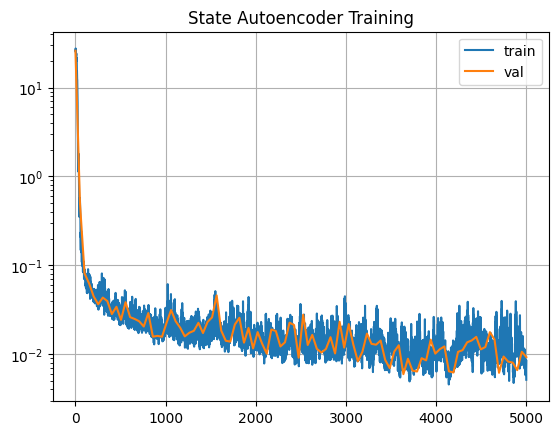

Test loss: 0.008543728850781918


In [3]:
# ---- Train State Autoencoder ----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Dataset
# ----------------------------
N = 120000

q_start_dataset = (torch.rand(N, 3) * 4 * np.pi) - 2 * np.pi
q_goal_dataset  = (torch.rand(N, 3) * 4 * np.pi) - 2 * np.pi

q_start_dataset = q_start_dataset.float()
q_goal_dataset  = q_goal_dataset.float()

# ----------------------------
# Split
# ----------------------------
p_train = 0.75
p_val   = 0.125
p_test  = 0.125
N_train = int(N * p_train)
N_val   = int(N * p_val)
N_test  = N - N_train - N_val

perm = torch.randperm(N)

train_idx = perm[:N_train]
val_idx   = perm[N_train:N_train + N_val]
test_idx  = perm[N_train + N_val:]

# ----------------------------
# Model
# ----------------------------
model = models.StateAutoEncoder(dof=3, latent_dim=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# Evaluation
# ----------------------------
def evaluate(indices):
    model.eval()

    q_start = q_start_dataset[indices].to(device)
    q_goal  = q_goal_dataset[indices].to(device)

    with torch.no_grad():
        q_start_rec, q_goal_rec, _ = model(q_start, q_goal)

        loss = (
            F.mse_loss(q_start_rec, q_start) +
            F.mse_loss(q_goal_rec, q_goal)
        )

    return loss.item()

# ----------------------------
# Training
# ----------------------------
batch_size = 64
epochs = 5000

train_history = []
val_history = []

for epoch in tqdm(range(epochs), desc="Training State Autoencoder"):

    model.train()

    idx = train_idx[torch.randint(0, len(train_idx), (batch_size,))]

    q_start = q_start_dataset[idx].to(device)
    q_goal  = q_goal_dataset[idx].to(device)

    opt.zero_grad()

    q_start_rec, q_goal_rec, _ = model(q_start, q_goal)

    loss = (
        F.mse_loss(q_start_rec, q_start) +
        F.mse_loss(q_goal_rec, q_goal)
    )

    loss.backward()
    opt.step()

    train_history.append(loss.item())

    if epoch % 50 == 0:
        val_history.append(evaluate(val_idx))

# ----------------------------
# Plot
# ----------------------------
plt.figure()
plt.plot(train_history, label="train")
plt.yscale("log")
plt.plot(
    np.linspace(0, len(train_history), len(val_history)),
    val_history,
    label="val"
)
plt.legend()
plt.grid()
plt.title("State Autoencoder Training")
plt.show()

print("Test loss:", evaluate(test_idx))

# ----------------------------
# Save
# ----------------------------
torch.save(model.state_dict(), "models/state_autoencoder.pt")
torch.save(model.encoder.state_dict(), "models/state_encoder.pt")

In [ ]:
def build_sdf_from_obstacles(obstacles, grid_length=2.5, number_of_vox=128):
    grid = SquareGrid(
        data=np.zeros((number_of_vox, number_of_vox)),
        length=grid_length,
        origin=SE2.identity()
    )
    x = np.linspace(-grid_length/2, grid_length/2, number_of_vox)
    y = np.linspace(-grid_length/2, grid_length/2, number_of_vox)
    X, Y = np.meshgrid(x, y)
    for i in range(len(obstacles.r)):
        dist_to_center = np.sqrt((X - obstacles.x[i])**2 + (Y - obstacles.y[i])**2)
        grid.data[dist_to_center <= obstacles.r[i]] = 1.0
    sdf = grid.derive_sdf_from_voxels().data
    return torch.from_numpy(sdf).float().unsqueeze(0)

def sample_obstacles(n_obs=3):
    xy = np.random.uniform(-1.0, 1.0, size=(n_obs, 2))
    r  = np.random.uniform(0.05, 0.2, size=(n_obs,))
    return xy, r

def generate_env_dataset(N, seed=42):
    np.random.seed(seed)
    sdf_list = []
    for _ in tqdm(range(N), desc="Generating SDF dataset"):
        xy, r = sample_obstacles(3)
        obstacles = Obstacles(x=xy[:, 0], y=xy[:, 1], r=r)
        sdf_list.append(build_sdf_from_obstacles(obstacles))
    return torch.stack(sdf_list)

In [ ]:
# Create environment dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N = 12000
DATA_PATH = "data/sdf_dataset.pt"

sdf_dataset = generate_env_dataset(N, seed=42)
torch.save(sdf_dataset, DATA_PATH)
print(f"sdf_dataset erzeugt und gespeichert: {sdf_dataset.shape}")

In [ ]:
# ---- Train Environment Autoencoder ----

# ----------------------------
# Cache: load or generate
# ----------------------------
os.makedirs("data", exist_ok=True)

if os.path.exists(DATA_PATH):
    sdf_dataset = torch.load(DATA_PATH, weights_only=True)
    print(f"sdf_dataset geladen: {sdf_dataset.shape}")
else:
    sdf_dataset = generate_env_dataset(N, seed=42)
    torch.save(sdf_dataset, DATA_PATH)
    print(f"sdf_dataset erzeugt und gespeichert: {sdf_dataset.shape}")

# ----------------------------
# Split
# ----------------------------
perm = torch.randperm(N)
N_train = int(0.75 * N)
N_val   = int(0.125 * N)
train_idx = perm[:N_train]
val_idx   = perm[N_train:N_train + N_val]
test_idx  = perm[N_train + N_val:]

# ----------------------------
# Model
# ----------------------------
model = models.EnvAutoEncoder(latent_dim=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(indices):
    model.eval()
    sdf = sdf_dataset[indices].to(device)
    with torch.no_grad():
        sdf_rec, _ = model(sdf)
        loss = F.mse_loss(sdf_rec, sdf)
    return loss.item()

# ----------------------------
# Training
# ----------------------------
batch_size = 64
epochs = 5000

train_history = []
val_history = []

for epoch in tqdm(range(epochs), desc="Training Env Autoencoder"):

    model.train()
    idx = train_idx[torch.randint(0, len(train_idx), (batch_size,))]
    sdf = sdf_dataset[idx].to(device)

    opt.zero_grad()
    sdf_rec, z = model(sdf)
    loss = F.mse_loss(sdf_rec, sdf)
    loss.backward()
    opt.step()

    train_history.append(loss.item())
    if epoch % 50 == 0:
        val_history.append(evaluate(val_idx))

# ----------------------------
# Plot
# ----------------------------
plt.figure()
plt.plot(train_history, label="train")
plt.yscale("log")
plt.plot(
    np.linspace(0, len(train_history), len(val_history)),
    val_history,
    label="val"
)
plt.legend()
plt.grid()
plt.title("Environment Autoencoder Training")
plt.show()

print("Test loss:", evaluate(test_idx))

# ----------------------------
# Save
# ----------------------------
torch.save(model.state_dict(), "models/env_autoencoder.pt")
torch.save(model.encoder.state_dict(), "models/env_encoder.pt")

SDF dataset: torch.Size([12000, 1, 128, 128])


Training WarmStartPlanner:   0%|          | 0/2000 [00:00<?, ?it/s]

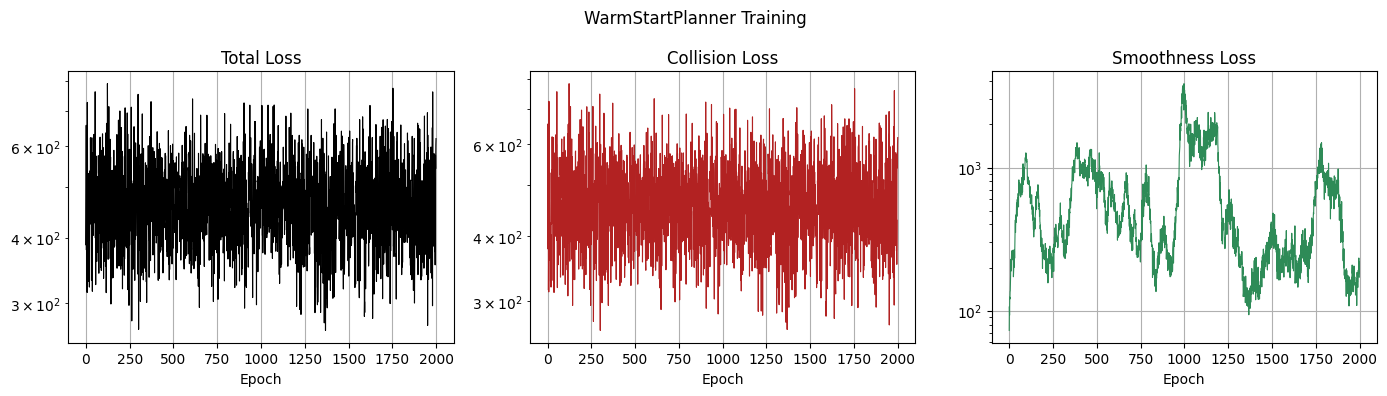

Gespeichert: models/warm_start_planner.pt
Metrik                             Mean       Min       Max
--------------------------------------------------------
Kollisionsrate................    4.4%     0.0%    19.7%
Smoothness Cost............... 203.4425   58.8799  525.5768
Endpoint-Fehler (rad).........  0.00000   0.00000   0.00000


In [3]:
# ---- Train WarmStartPlanner ----

from simplearm.robot import RobotInfo
from losses import compute_smoothness_cost, compute_trajectory_collision_cost
from utils import get_world_spheres_torch, query_sdf_differentiable

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Robot & SDF dataset
# ----------------------------
linklengths = [0.5, 0.4, 0.3]
robot = RobotInfo.from_linklengths(linklengths, sphere_rad=0.08)

DATA_PATH = "data/sdf_dataset.pt"
sdf_dataset = torch.load(DATA_PATH, weights_only=True)  # [N, 1, H, W]
N_env = len(sdf_dataset)
print(f"SDF dataset: {sdf_dataset.shape}")

# ----------------------------
# Model — load pre-trained encoders, only train decoder
# ----------------------------
planner = models.WarmStartPlanner(dof=3, T=50).to(device)

planner.env_encoder.load_state_dict(torch.load("models/env_encoder.pt", weights_only=True))
planner.state_encoder.load_state_dict(torch.load("models/state_encoder.pt", weights_only=True))

for p in planner.env_encoder.parameters():
    p.requires_grad = False
for p in planner.state_encoder.parameters():
    p.requires_grad = False

opt = torch.optim.Adam(planner.decoder.parameters(), lr=1e-3)

# ----------------------------
# Training
# ----------------------------
batch_size = 32
epochs     = 2000
dof        = 3

total_history  = []
smooth_history = []
coll_history   = []

for epoch in tqdm(range(epochs), desc="Training WarmStartPlanner"):

    planner.train()

    env_idx   = torch.randint(0, N_env, (batch_size,))
    sdf_batch = sdf_dataset[env_idx].to(device)

    q_start = torch.rand(batch_size, dof, device=device) * 2 * torch.pi - torch.pi
    q_goal  = torch.rand(batch_size, dof, device=device) * 2 * torch.pi - torch.pi

    opt.zero_grad()
    q_traj = planner(q_start, q_goal, sdf_batch)
    B, T, _ = q_traj.shape

    loss_smooth = compute_smoothness_cost(q_traj, dt=0.1)
    loss_coll   = compute_trajectory_collision_cost(q_traj, sdf_batch, robot, weight=B * T * 5.0)
    loss        = 0.01 * loss_smooth + loss_coll

    loss.backward()
    opt.step()

    total_history.append(loss.item())
    smooth_history.append(loss_smooth.item())
    coll_history.append(loss_coll.item())

# ----------------------------
# Training plots
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, history, title, color in zip(
    axes,
    [total_history, coll_history, smooth_history],
    ["Total Loss", "Collision Loss", "Smoothness Loss"],
    ["black", "firebrick", "seagreen"],
):
    ax.plot(history, color=color, linewidth=0.8)
    ax.set_title(title)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.grid(True)
plt.suptitle("WarmStartPlanner Training")
plt.tight_layout()
plt.show()

# ----------------------------
# Save
# ----------------------------
torch.save(planner.state_dict(), "models/warm_start_planner.pt")
print("Gespeichert: models/warm_start_planner.pt")

# ----------------------------
# Validation — Metriken ohne Plot
# ----------------------------
N_CASES  = 20
GRID_LEN = 2.5
torch.manual_seed(42)

planner.eval()

coll_rates     = []
smooth_costs   = []
endpoint_errs  = []

with torch.no_grad():
    for _ in range(N_CASES):
        env_idx = torch.randint(0, N_env, (1,))
        sdf_t   = sdf_dataset[env_idx].to(device)

        q_start = torch.rand(1, dof, device=device) * 2 * torch.pi - torch.pi
        q_goal  = torch.rand(1, dof, device=device) * 2 * torch.pi - torch.pi

        q_traj  = planner(q_start, q_goal, sdf_t)   # [1, T, dof]
        q_steps = q_traj[0].cpu()                   # [T, dof]

        # Kollisionsrate
        spheres = get_world_spheres_torch(q_steps, robot)
        dists   = query_sdf_differentiable(sdf_t[0, 0].cpu(), spheres.reshape(-1, 2), GRID_LEN)
        coll_rates.append((dists < 0).float().mean().item())

        # Smoothness
        smooth_costs.append(compute_smoothness_cost(q_steps.unsqueeze(0), dt=0.1).item())

        # Endpoint-Fehler (sollte ~0 sein dank Interpolation)
        err_start = (q_traj[0, 0]  - q_start[0]).norm().item()
        err_goal  = (q_traj[0, -1] - q_goal[0]).norm().item()
        endpoint_errs.append((err_start + err_goal) / 2)

print(f"{'Metrik':<30} {'Mean':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 56)
print(f"{'Kollisionsrate':.<30} {np.mean(coll_rates):>7.1%}  {np.min(coll_rates):>7.1%}  {np.max(coll_rates):>7.1%}")
print(f"{'Smoothness Cost':.<30} {np.mean(smooth_costs):>8.4f}  {np.min(smooth_costs):>8.4f}  {np.max(smooth_costs):>8.4f}")
print(f"{'Endpoint-Fehler (rad)':.<30} {np.mean(endpoint_errs):>8.5f}  {np.min(endpoint_errs):>8.5f}  {np.max(endpoint_errs):>8.5f}")


[464.82965087890625, 363.7485046386719, 595.8213500976562, 421.6507873535156, 706.640380859375, 452.4358215332031, 527.6458740234375, 472.76190185546875, 441.1835632324219, 713.5877075195312, 468.97552490234375, 422.8529968261719, 679.8501586914062, 489.0442810058594, 539.61328125, 650.3048095703125, 388.44989013671875, 401.4980163574219, 294.12188720703125, 347.06134033203125, 350.8968505859375, 519.9183959960938, 316.5299377441406, 473.9890441894531, 511.17657470703125, 588.3340454101562, 446.611572265625, 322.68634033203125, 527.76171875, 342.5149841308594, 779.9321899414062, 570.2459106445312, 437.33807373046875, 345.92474365234375, 612.8899536132812, 454.2395935058594, 370.6570739746094, 333.6203308105469, 411.7075500488281, 589.8275756835938, 606.5967407226562, 432.9360656738281, 476.43280029296875, 621.4378051757812, 538.4320678710938, 536.8494262695312, 375.2134704589844, 459.7545471191406, 660.5352783203125, 539.1954345703125, 650.2002563476562, 432.01171875, 429.7179260253906